# Notebook 19: Multi-Armed Bandits

**Series:** Reinforcement Learning Basics (19/20)

---

## 1. The Multi-Armed Bandit Problem

$K$ slot machines ("arms"), each with unknown reward distribution. Goal: maximize total reward over $T$ pulls.

**Formally:** Maximize $\mathbb{E}\left[\sum_{t=1}^T R_t\right]$

### Regret
$$L_T = T \cdot \mu^* - \mathbb{E}\left[\sum_{t=1}^T R_t\right]$$

where $\mu^* = \max_k \mu_k$ is the best arm's mean reward.

**Goal:** Minimize regret = find the best arm quickly.

## 2. Action-Value Estimation

**Sample average:** $Q_t(a) = \frac{\sum_{i=1}^{t-1} R_i \cdot \mathbb{1}(A_i = a)}{N_t(a)}$

**Incremental update:** $Q_{n+1}(a) = Q_n(a) + \frac{1}{n}[R_n - Q_n(a)]$

**Non-stationary (exponential recency):**
$$Q_{n+1}(a) = Q_n(a) + \alpha[R_n - Q_n(a)]$$
$$= (1-\alpha)^n Q_1 + \sum_{i=1}^n \alpha(1-\alpha)^{n-i} R_i$$

## 3. Gradient Bandit Algorithm

Learn **preferences** $H_t(a)$ instead of values:

$$\pi_t(a) = \frac{e^{H_t(a)}}{\sum_b e^{H_t(b)}}$$

**Update:**
$$H_{t+1}(a) = H_t(a) + \alpha(R_t - \bar{R}_t)(\mathbb{1}(A_t = a) - \pi_t(a))$$

where $\bar{R}_t$ is the average reward baseline.

## 4. Contextual Bandits

State/context $s_t$ is observed before choosing action. Bridge between bandits and full RL.

$$a_t = \arg\max_a Q(s_t, a)$$

Applications: news recommendation, ad placement, clinical trials.

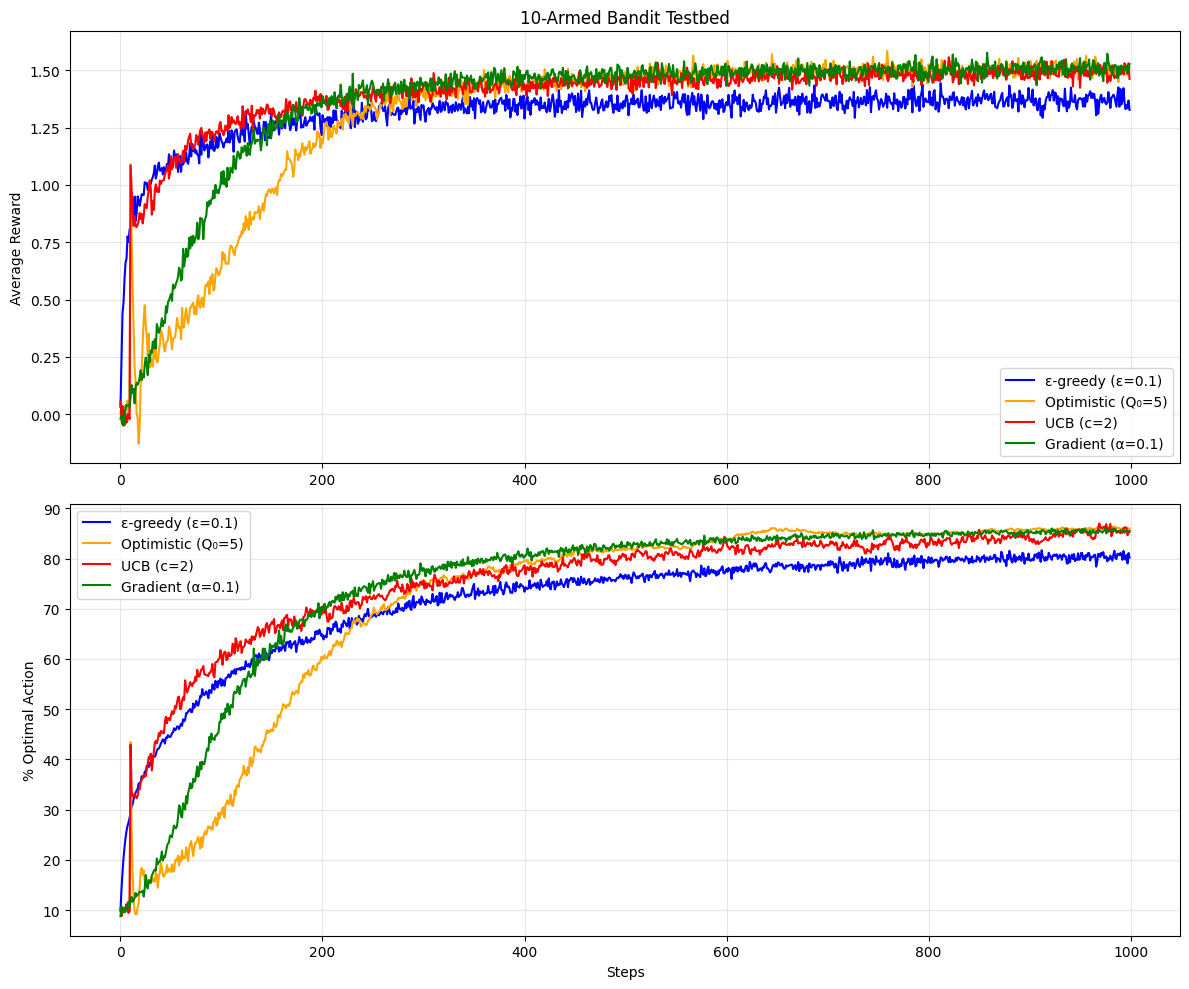

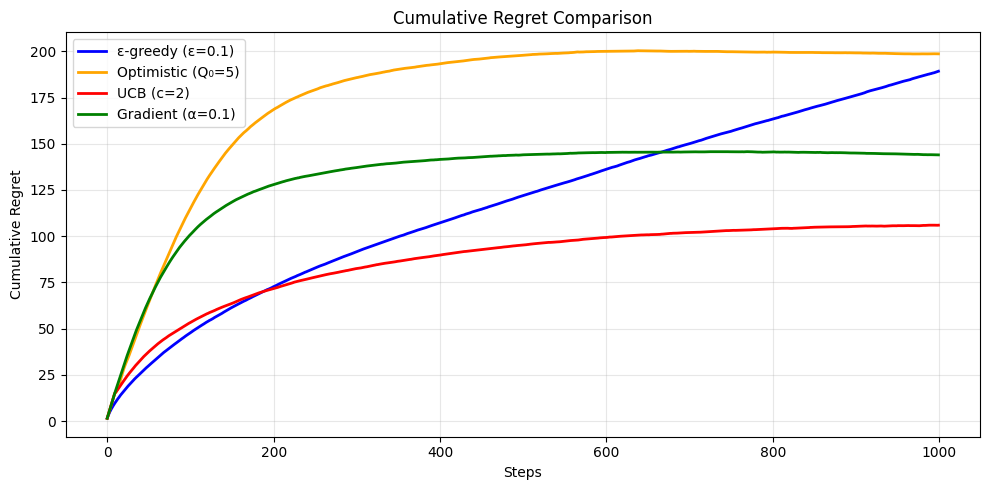

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# Comprehensive Bandit Comparison
# ============================================
class KArmedBandit:
    def __init__(self, k=10, stationary=True):
        self.k = k
        self.q_star = np.random.randn(k)
        self.stationary = stationary

    def pull(self, action):
        if not self.stationary:
            self.q_star += np.random.randn(self.k) * 0.01
        return np.random.randn() + self.q_star[action]

    def optimal_action(self):
        return np.argmax(self.q_star)

def gradient_bandit(bandit, alpha=0.1, n_steps=1000):
    H = np.zeros(bandit.k)
    avg_reward = 0
    rewards = []; optimal = []

    for t in range(n_steps):
        probs = np.exp(H - np.max(H))
        probs /= probs.sum()
        action = np.random.choice(bandit.k, p=probs)
        reward = bandit.pull(action)
        avg_reward += (reward - avg_reward) / (t + 1)

        one_hot = np.zeros(bandit.k)
        one_hot[action] = 1
        H += alpha * (reward - avg_reward) * (one_hot - probs)

        rewards.append(reward)
        optimal.append(1 if action == bandit.optimal_action() else 0)
    return rewards, optimal

def optimistic_greedy(bandit, Q_init=5.0, alpha=0.1, n_steps=1000):
    Q = np.full(bandit.k, Q_init)
    N = np.zeros(bandit.k)
    rewards = []; optimal = []

    for t in range(n_steps):
        action = np.argmax(Q)
        reward = bandit.pull(action)
        N[action] += 1
        Q[action] += alpha * (reward - Q[action])
        rewards.append(reward)
        optimal.append(1 if action == bandit.optimal_action() else 0)
    return rewards, optimal

# Run all methods
n_runs = 2000; n_steps = 1000
all_methods = {
    'ε-greedy (ε=0.1)': lambda b: (lambda: __import__('__main__').run_eps(b, 0.1))(),
    'Optimistic (Q₀=5)': lambda b: optimistic_greedy(b, Q_init=5.0),
    'UCB (c=2)': lambda b: (lambda: __import__('__main__').run_ucb_b(b, 2))(),
    'Gradient (α=0.1)': lambda b: gradient_bandit(b, alpha=0.1),
}

# Inline helpers
def run_eps(b, eps):
    Q=np.zeros(b.k);N=np.zeros(b.k);rs=[];os=[]
    for t in range(1000):
        a=np.random.randint(b.k) if np.random.random()<eps else np.argmax(Q)
        r=b.pull(a);N[a]+=1;Q[a]+=(r-Q[a])/N[a];rs.append(r)
        os.append(1 if a==b.optimal_action() else 0)
    return rs,os

def run_ucb_b(b, c):
    Q=np.zeros(b.k);N=np.zeros(b.k);rs=[];os=[]
    for t in range(1000):
        if 0 in N: a=np.argmin(N)
        else: a=np.argmax(Q+c*np.sqrt(np.log(t+1)/N))
        r=b.pull(a);N[a]+=1;Q[a]+=(r-Q[a])/N[a];rs.append(r)
        os.append(1 if a==b.optimal_action() else 0)
    return rs,os

methods = {
    'ε-greedy (ε=0.1)': lambda b: run_eps(b, 0.1),
    'Optimistic (Q₀=5)': lambda b: optimistic_greedy(b, Q_init=5.0),
    'UCB (c=2)': lambda b: run_ucb_b(b, 2),
    'Gradient (α=0.1)': lambda b: gradient_bandit(b, alpha=0.1),
}

results = {n: {'rewards': np.zeros(n_steps), 'optimal': np.zeros(n_steps)} for n in methods}
for _ in range(n_runs):
    bandit = KArmedBandit(10)
    for name, fn in methods.items():
        r, o = fn(bandit)
        results[name]['rewards'] += np.array(r)
        results[name]['optimal'] += np.array(o)

fig, axes = plt.subplots(2, 1, figsize=(12, 10))
colors = ['blue', 'orange', 'red', 'green']
for i, (name, data) in enumerate(results.items()):
    axes[0].plot(data['rewards']/n_runs, label=name, color=colors[i], linewidth=1.5)
    axes[1].plot(data['optimal']/n_runs*100, label=name, color=colors[i], linewidth=1.5)

axes[0].set_ylabel('Average Reward'); axes[0].set_title('10-Armed Bandit Testbed')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].set_xlabel('Steps'); axes[1].set_ylabel('% Optimal Action')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Regret comparison
fig, ax = plt.subplots(figsize=(10, 5))
for i, (name, data) in enumerate(results.items()):
    avg_rewards = data['rewards'] / n_runs
    # Estimate optimal reward per step (approximately the max q_star mean)
    cumulative_regret = np.cumsum(1.5 - avg_rewards)  # rough optimal
    ax.plot(cumulative_regret, label=name, color=colors[i], linewidth=2)
ax.set_xlabel('Steps'); ax.set_ylabel('Cumulative Regret')
ax.set_title('Cumulative Regret Comparison')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

| Method | Regret Bound | Key Idea |
|--------|-------------|----------|
| **ε-greedy** | $O(\varepsilon T)$ | Fixed exploration rate |
| **Optimistic** | Depends on init | Encourages initial exploration |
| **UCB** | $O(\sqrt{KT \ln T})$ | Confidence-based exploration |
| **Thompson** | $O(\sqrt{KT \ln T})$ | Posterior sampling |
| **Gradient** | — | Learn preferences via gradient |

**Next:** Notebook 20 — Model-Based RL